# Calibration du Modèle SABR sur les Options AAPL

Ce notebook présente le **workflow quantitatif complet** de bout en bout :

1. Extraction des données de marché via `yfinance` et calcul des volatilités implicites (Newton-Raphson).
2. Calibration du modèle SABR — formule approchée de Hagan (2002) — par optimisation L-BFGS-B.
3. Simulation Monte Carlo vectorisée par schéma d'Euler-Maruyama.
4. Pricing d'options asiatiques et vanilles, Grecs par différences finies et validation du modèle.

---

## Théorie 1 — Inversion de Black-Scholes : Volatilité Implicite

Pour extraire $\sigma_{impl}$ à partir du prix observé $C_{market}$, on inverse numériquement le modèle de Black-Scholes par la méthode de **Newton-Raphson**.

### Prix d'un call européen Black-Scholes

$$C_{BS}(S, K, T, r, \sigma) = S \cdot \mathcal{N}(d_1) - K\, e^{-rT} \cdot \mathcal{N}(d_2)$$

$$d_1 = \frac{\ln(S/K) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

### Vega — dérivée par rapport à $\sigma$

$$\mathcal{V} = \frac{\partial C_{BS}}{\partial \sigma} = S\sqrt{T}\cdot \mathcal{N}'(d_1)$$

### Itération de Newton-Raphson

$$\sigma_{n+1} = \sigma_n - \frac{C_{BS}(\sigma_n) - C_{market}}{\mathcal{V}(\sigma_n)}$$

L'algorithme converge en général en quelques itérations. Si le vega s'écrase (strike très hors-la-monnaie), on retourne `NaN` et le point est filtré.

## Théorie 2 — Le Modèle SABR : EDS et Lemme d'Itô

Le modèle **SABR** (Stochastic Alpha Beta Rho) est défini sous la mesure risque-neutre (cas $\beta = 1$, log-normal) par le système :

$$dS_t = r\, S_t\, dt + \alpha_t\, S_t\, dW_t^S$$

$$d\alpha_t = \nu\, \alpha_t\, dW_t^{\alpha}$$

avec la structure de corrélation $d\langle W^S,\, W^{\alpha} \rangle_t = \rho\, dt$ et les paramètres :

| Paramètre | Rôle |
|-----------|------|
| $\alpha_0$ | Volatilité initiale (ATM forward vol) |
| $\nu$ | Vol-of-vol (amplitude des fluctuations de $\alpha_t$) |
| $\rho$ | Corrélation spot-vol (contrôle le skew du smile) |

### Application du Lemme d'Itô à $\ln \alpha_t$

Posons $f(\alpha) = \ln \alpha$. Par le lemme d'Itô :

$$d\ln \alpha_t = \frac{1}{\alpha_t}\,d\alpha_t - \frac{1}{2\alpha_t^2}\,(d\alpha_t)^2 = -\frac{\nu^2}{2}\,dt + \nu\,dW_t^{\alpha}$$

En intégrant, on obtient la solution **exacte** :

$$\alpha_t = \alpha_0\,\exp\!\left(-\frac{\nu^2}{2}\,t + \nu\, W_t^{\alpha}\right)$$

### Formule approchée de Hagan (2002)

Pour le forward $F_0 = S_0 e^{rT}$, la volatilité implicite Black approchée est :

$$\sigma_{SABR}(K, T) \approx \frac{\alpha_0\,\eta}{x(\eta)} \cdot \left[1 + \left(\frac{(2-3\rho^2)\nu^2}{24} + \frac{\rho\,\alpha_0\,\nu}{4}\right)T\right]$$

$$\eta = \frac{\nu}{\alpha_0}\ln\frac{F_0}{K}, \qquad x(\eta) = \ln\frac{\sqrt{1-2\rho\eta+\eta^2}+\eta-\rho}{1-\rho}$$

Le cas ATM ($K = F_0$) est traité séparément pour éviter la forme indéterminée $0/0$.

## Théorie 3 — Schéma d'Euler-Maruyama

On discrétise le système d'EDS sur $N$ pas de temps $\Delta t = T/N$. En appliquant le lemme d'Itô à $\ln S_t$ et $\ln \alpha_t$, on obtient des schémas **log-normaux exacts** (pas de biais de discrétisation) :

$$\ln \alpha_{t+\Delta t} = \ln \alpha_t - \frac{\nu^2}{2}\,\Delta t + \nu\sqrt{\Delta t}\; Z_2^{(k)}$$

$$\ln S_{t+\Delta t} = \ln S_t + \left(r - \frac{\alpha_t^2}{2}\right)\Delta t + \alpha_t\sqrt{\Delta t}\; Z_1^{(k)}$$

Les innovations corrélées sont construites par décomposition de Cholesky :

$$Z_2 = \rho\,Z_1 + \sqrt{1-\rho^2}\;\tilde{Z}_2, \qquad (Z_1,\,\tilde{Z}_2) \overset{i.i.d.}{\sim} \mathcal{N}(0,1)$$

Les $M$ trajectoires sont calculées **simultanément** sous forme de matrices NumPy de forme $(M \times N)$, ce qui vectorise entièrement la simulation.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sabr_pricing import (
    MarketData,
    SABRCalibrator,
    SABRSimulator,
    AsianCallPricer,
    VanillaCallPricer,
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
print('Librairie sabr_pricing chargee avec succes.')

Librairie sabr_pricing chargee avec succes.


---
## Étape 1 — Extraction et Traitement des Données de Marché

La classe `MarketData` encapsule :
- La récupération du prix spot et de la chaîne d'options via `yfinance`.
- Le filtrage des strikes autour du spot ($\pm 20\%$).
- L'inversion Newton-Raphson de Black-Scholes pour obtenir $\sigma_{impl}(K)$ pour chaque strike.

In [3]:
data = MarketData(ticker='AAPL', rate=0.045)

S0 = data.fetch_spot()
print(f'Prix Spot AAPL (S0) : {S0:.2f} $')
print(f'Echeances disponibles : {data.get_expiries()[:5]}')

# 3eme echeance, filtre +/-20% du spot, prix minimum 0.10 $
df_calls = data.load_chain(expiry_index=2, spot_range=0.20, min_price=0.10)
T      = data.T
r      = data.rate
expiry = data.expiry

print()
print(f'Echeance selectionnee : {expiry}  (T = {T:.4f} ans)')
print()
print(df_calls[['strike', 'lastPrice', 'vol_implicite']].to_string(index=False))

Prix Spot AAPL (S0) : 301.54 $
Echeances disponibles : ('2026-06-08', '2026-06-10', '2026-06-12', '2026-06-15', '2026-06-17')

Echeance selectionnee : 2026-06-12  (T = 0.0082 ans)

 strike  lastPrice  vol_implicite
  287.5      15.90       0.613446
  290.0      12.60       0.431956
  292.5      10.46       0.416850
  295.0       8.52       0.410265
  297.5       6.70       0.398184
  300.0       5.15       0.393116
  302.5       3.79       0.384760
  305.0       2.68       0.377672
  307.5       1.88       0.378568
  310.0       1.25       0.376059
  312.5       0.84       0.380320
  315.0       0.55       0.384192
  317.5       0.39       0.397565
  320.0       0.27       0.408377
  322.5       0.20       0.424402


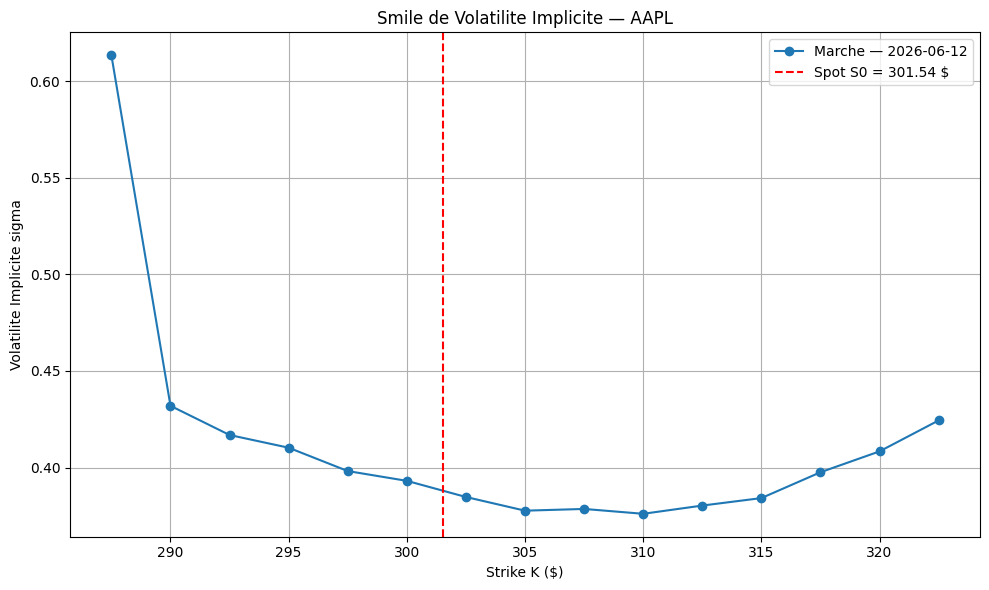

In [4]:
fig, ax = plt.subplots()
ax.plot(df_calls['strike'], df_calls['vol_implicite'], 'o-', label=f'Marche — {expiry}')
ax.axvline(x=S0, color='r', linestyle='--', label=f'Spot S0 = {S0:.2f} $')
ax.set_title('Smile de Volatilite Implicite — AAPL')
ax.set_xlabel('Strike K ($)')
ax.set_ylabel('Volatilite Implicite sigma')
ax.legend()
plt.tight_layout()
plt.show()

---
## Étape 2 — Calibration du Modèle SABR

La classe `SABRCalibrator` ajuste les paramètres $(\alpha_0, \rho, \nu)$ en minimisant la **somme des erreurs quadratiques** entre le smile SABR théorique et le smile de marché :

$$\min_{\alpha_0,\, \rho,\, \nu} \sum_{i=1}^{N} \left(\sigma_{SABR}(K_i) - \sigma_{market}(K_i)\right)^2$$

sous les contraintes $\alpha_0 > 0$, $\rho \in (-1, 1)$, $\nu > 0$, via l'algorithme **L-BFGS-B**.

In [5]:
calibrator = SABRCalibrator()
strikes     = df_calls['strike'].values
market_vols = df_calls['vol_implicite'].values

params = calibrator.calibrate(strikes, market_vols, S0, r, T)

print(f'Calibration reussie : {calibrator.result.success}')
print(f'  alpha0 (alpha) : {params.alpha:.4f}')
print(f'  rho           : {params.rho:.4f}')
print(f'  nu            : {params.nu:.4f}')

Calibration reussie : True
  alpha0 (alpha) : 0.3619
  rho           : -0.3477
  nu            : 9.8399


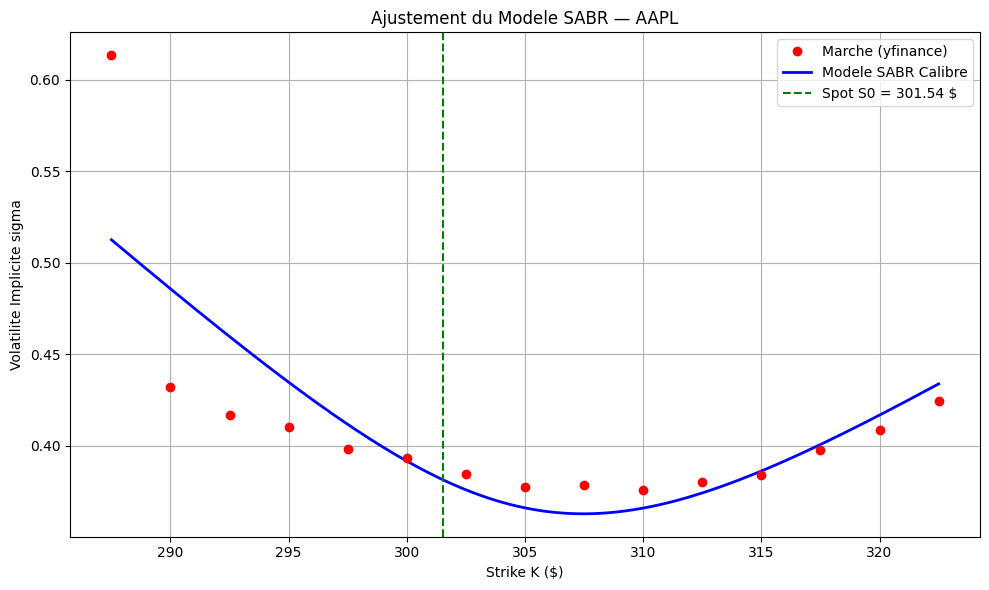

In [6]:
strikes_smooth = np.linspace(strikes.min(), strikes.max(), 200)
vols_sabr      = calibrator.smile(strikes_smooth, S0, r, T)

fig, ax = plt.subplots()
ax.plot(strikes, market_vols, 'ro', label='Marche (yfinance)', zorder=5)
ax.plot(strikes_smooth, vols_sabr, 'b-', label='Modele SABR Calibre', linewidth=2)
ax.axvline(x=S0, color='g', linestyle='--', label=f'Spot S0 = {S0:.2f} $')
ax.set_title('Ajustement du Modele SABR — AAPL')
ax.set_xlabel('Strike K ($)')
ax.set_ylabel('Volatilite Implicite sigma')
ax.legend()
plt.tight_layout()
plt.show()

---
## Étape 3 — Simulation Monte Carlo SABR

La classe `SABRSimulator` génère $M$ trajectoires simultanées sous forme d'une matrice NumPy de forme $(M \times N+1)$ :
- **Lignes** : scénarios Monte Carlo indépendants.
- **Colonnes** : pas de temps $t_0 = 0,\, t_1,\, \ldots,\, t_N = T$.

La graine aléatoire est fixée pour assurer la **reproductibilité** des résultats.

Forme de la matrice de trajectoires : (50000, 253)
  50,000 scenarios x 253 pas de temps

Prix final median  : 302.69 $
Prix final moyen   : 301.64 $
Ecart-type final   : 12.09 $


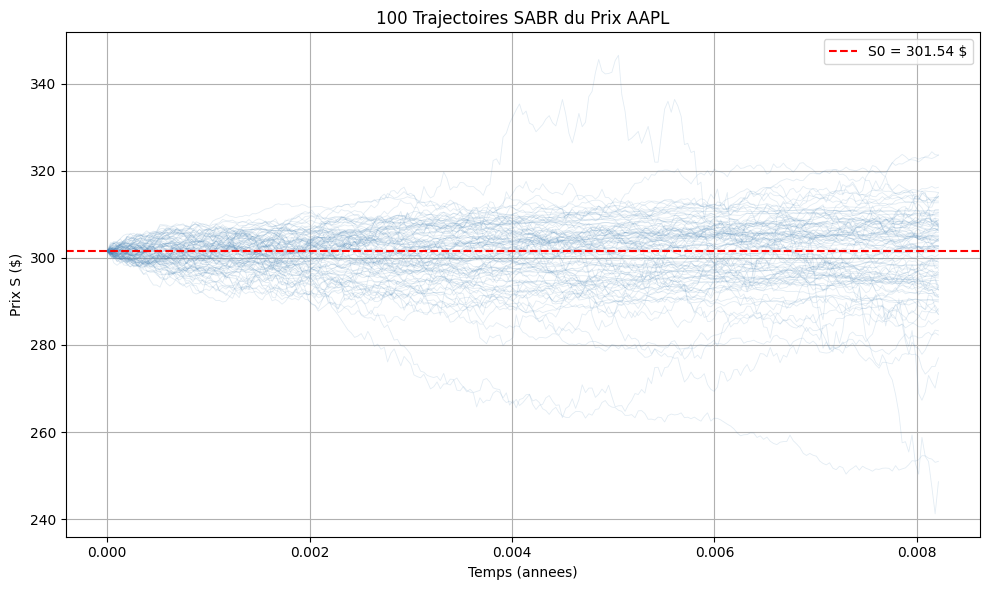

In [7]:
N_PATHS = 50_000
N_STEPS = 252  # un pas par jour ouvre

simulator    = SABRSimulator(alpha=params.alpha, rho=params.rho, nu=params.nu)
trajectoires = simulator.simulate(S0, r, T, N_PATHS, N_STEPS, seed=42)

print(f'Forme de la matrice de trajectoires : {trajectoires.shape}')
print(f'  {N_PATHS:,} scenarios x {N_STEPS + 1} pas de temps')
print()
print(f'Prix final median  : {np.median(trajectoires[:, -1]):.2f} $')
print(f'Prix final moyen   : {np.mean(trajectoires[:, -1]):.2f} $')
print(f'Ecart-type final   : {np.std(trajectoires[:, -1]):.2f} $')

# Visualisation de 100 trajectoires
t_grid = np.linspace(0, T, N_STEPS + 1)
fig, ax = plt.subplots()
for i in range(100):
    ax.plot(t_grid, trajectoires[i], alpha=0.15, linewidth=0.6, color='steelblue')
ax.axhline(y=S0, color='r', linestyle='--', linewidth=1.5, label=f'S0 = {S0:.2f} $')
ax.set_title('100 Trajectoires SABR du Prix AAPL')
ax.set_xlabel('Temps (annees)')
ax.set_ylabel('Prix S ($)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Étape 4 — Pricing des Options par Monte Carlo

### Option Asiatique à Moyenne Arithmétique

Le payoff dépend de la **moyenne temporelle** du prix :

$$C_{Asian} = e^{-rT}\,\mathbb{E}\!\left[\max\!\left(\bar{S} - K,\; 0\right)\right], \qquad \bar{S} = \frac{1}{N+1}\sum_{k=0}^{N} S_{t_k}$$

### Option Vanille Européenne

Le payoff dépend uniquement du **prix final** $S_T$ :

$$C_{Vanilla} = e^{-rT}\,\mathbb{E}\!\left[\max\!\left(S_T - K,\; 0\right)\right]$$

L'espérance est approchée par la moyenne empirique sur les $M = 50\,000$ trajectoires.

In [8]:
K_atm = S0  # strike at-the-money

asian_pricer   = AsianCallPricer(simulator)
vanilla_pricer = VanillaCallPricer(simulator)

prix_asian   = asian_pricer.price(trajectoires, K_atm, r, T)
prix_vanilla = vanilla_pricer.price(trajectoires, K_atm, r, T)

print(f'Strike ATM (K)         : {K_atm:.2f} $')
print(f'Prix Asian Call SABR   : {prix_asian:.4f} $')
print(f'Prix Vanilla Call SABR : {prix_vanilla:.4f} $')
print()
print('Observation : le prix de la Vanille est superieur a celui de l Asian Call.')
print('La moyenne reduit la variance du payoff, abaissant mecaniquement le prix.')

Strike ATM (K)         : 301.54 $
Prix Asian Call SABR   : 2.3691 $
Prix Vanilla Call SABR : 4.1794 $

Observation : le prix de la Vanille est superieur a celui de l Asian Call.
La moyenne reduit la variance du payoff, abaissant mecaniquement le prix.


---
## Étape 5 — Calcul des Grecs par Différences Finies Centrées

Les Grecs sont estimés par **bump-and-reprice** avec la **même graine aléatoire** pour chaque simulation (variance commune réduite, ou *common random numbers*) :

$$\Delta = \frac{C(S_0+\varepsilon_S) - C(S_0-\varepsilon_S)}{2\,\varepsilon_S}$$

$$\Gamma = \frac{C(S_0+\varepsilon_S) - 2\,C(S_0) + C(S_0-\varepsilon_S)}{\varepsilon_S^2}$$

$$\mathcal{V} = \frac{C(\alpha_0+\varepsilon_{\alpha}) - C(\alpha_0-\varepsilon_{\alpha})}{2\,\varepsilon_{\alpha}}$$

avec $\varepsilon_S = 1\%\cdot S_0$ et $\varepsilon_{\alpha} = 1\%\cdot \alpha_0$.

In [9]:
print('Calcul des Grecs (5 re-simulations x 50 000 trajectoires)...')
print()

greeks_dict = asian_pricer.greeks(S0, r, T, K_atm, N_PATHS, N_STEPS)

delta = greeks_dict['delta']
gamma = greeks_dict['gamma']
vega  = greeks_dict['vega']

print('--- Grecs de l Option Asiatique (K = ATM) ---')
print(f'  Delta  : {delta:.4f}    (dC/dS0   — sensibilite au spot)')
print(f'  Gamma  : {gamma:.6f}    (d2C/dS02 — convexite)')
print(f'  Vega   : {vega:.4f}    (dC/dalpha0 — sensibilite a la vol initiale)')

Calcul des Grecs (5 re-simulations x 50 000 trajectoires)...

--- Grecs de l Option Asiatique (K = ATM) ---
  Delta  : 0.5398    (dC/dS0   — sensibilite au spot)
  Gamma  : 0.072101    (d2C/dS02 — convexite)
  Vega   : 6.4517    (dC/dalpha0 — sensibilite a la vol initiale)


---
## Étape 6 — Vérification de la Cohérence du Modèle

On compare le prix Monte Carlo SABR d'un call **vanille ATM** avec le **prix de marché** observé sur Yahoo Finance.

$$\text{Erreur relative} = \frac{\left|C_{SABR} - C_{market}\right|}{C_{market}} \times 100\%$$

Une faible erreur valide la cohérence de bout en bout : calibration → simulation → pricing.

In [10]:
# Strike de marche le plus proche du spot
idx_atm    = (df_calls['strike'] - S0).abs().idxmin()
K_market   = df_calls.loc[idx_atm, 'strike']
prix_market = df_calls.loc[idx_atm, 'lastPrice']

# Prix Monte Carlo SABR pour ce strike
prix_mc = vanilla_pricer.price(trajectoires, K_market, r, T)

ecart_abs = abs(prix_mc - prix_market)
ecart_rel = (ecart_abs / prix_market) * 100.0

print('--- Verification de la Coherence du Modele ---')
print(f'  Strike teste (approx ATM)    : {K_market:.2f} $')
print(f'  Prix marche (Yahoo Finance)  : {prix_market:.4f} $')
print(f'  Prix Monte Carlo SABR        : {prix_mc:.4f} $')
print(f'  Ecart absolu                 : {ecart_abs:.4f} $')
print(f'  Ecart relatif                : {ecart_rel:.2f} %')

--- Verification de la Coherence du Modele ---
  Strike teste (approx ATM)    : 302.50 $
  Prix marche (Yahoo Finance)  : 3.7900 $
  Prix Monte Carlo SABR        : 3.6692 $
  Ecart absolu                 : 0.1208 $
  Ecart relatif                : 3.19 %
